In [58]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [59]:
data3 = pd.read_csv("Best Copy of Energy Data for CS ML 2000-2022 - Sheet1.csv")
future_data3 = pd.read_csv("Best Copy of Energy Data for CS ML 2000-2022 - Sheet1.csv")

for df in [data3, future_data3]:
    df["country"] = df["country"].str.strip()
    df["country_code"] = df["country"].astype("category").cat.codes
    df["renew/sus_elec_gen"] = df["elec_gen_solar"] + df["elec_gen_wind"] + df["elec_gen_hydro/tide"] + df["elec_gen_sol/geothermal"]
    df["elec_gen_total"] = (df["renew/sus_elec_gen"] + df["elec_gen_oil"] + df["elec_gen_coal"] + df["elec_gen_biofuels"] + 
                               df["elec_gen_natural_gas"] + df["elec_gen_nuclear"] + df["elec_gen_other"] + df["elec_gen_waste"])
    df["true_renew_share"] = df["renew/sus_elec_gen"] / df["elec_gen_total"]

data3["renew_share_next"] = data3.groupby("country_code")["true_renew_share"].shift(-1)
data3["renew_share_change"] = data3["renew_share_next"] - data3["true_renew_share"]
data3 = data3.dropna(subset=["renew_share_change"])

In [60]:
drop_cols = [
    "renew_share_change", "renew_share_next", "country", "co2_emissions_total", 
    "elec_gen_hydro", "elec_gen_tide", "elec_gen_geothermal",
    "elec_gen_solar_thermal", "elec_gen_sol/geothermal", "elec_gen_hydro/tide", 
    "elec_gen_solar", "elec_gen_wind", "elec_gen_total", "renew/sus_elec_gen",
    "co2_emissions_coal", "co2_emissions_oil", "co2_emissions_natural_gas", 
    "co2_emissions_other", "co2_emissions_elec_gen_incl_chp", "elec_gen_coal", 
    "elec_gen_oil", "elec_gen_natural_gas", "elec_gen_biofuels", "elec_gen_waste", 
    "elec_gen_nuclear", "elec_gen_other", "true_renew_share", "country_code"
]

X3 = data3.drop(columns=drop_cols)
y3 = data3["renew_share_change"]
X3_columns = X3.columns

In [61]:
from sklearn.ensemble import RandomForestRegressor

train = data3[data3["year"] <= 2017]
test = data3[data3["year"] > 2017]

X3_train = train[X3_columns]
y3_train = train["renew_share_change"]

X3_test = test[X3_columns]
y3_test = test["renew_share_change"]

RF_model3 = RandomForestRegressor(n_estimators=200, random_state=42)
RF_model3.fit(X3_train, y3_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
X3_train

,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,tfc_oil,tfc_natural_gas,tfc_solar_wind,tfc_biofuels,tfc_electricity,tfc_heat,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita
0,2000,2015828,806999,58896,0,3763,210841,1429894,175846,1453500,476844,3417,181752,621896,0,195.244,17.585955,45979.07657
1,2001,2018544,850415,59626,0,4531,212965,1281399,165416,1438847,503116,3617,180038,649432,0,206.484,17.690257,46314.62353
2,2002,2034808,788516,57157,0,5161,226713,1360752,125943,1417203,494640,3670,190811,688021,0,211.730,17.892464,47599.40793
3,2003,2015734,856586,58586,0,5521,219530,1480641,144840,1479100,529306,2775,145331,665769,0,207.548,17.665647,48509.66322
4,2004,2089200,859874,57996,0,5404,216460,1488010,151394,1525625,539122,2616,137087,681541,0,212.475,18.149135,50018.59045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,2013,18094904,25395330,975081,8967316,1132316,4183326,32389117,938505,30045148,14224665,99846,3268409,13558161,245688,4108.643,15.889418,54462.62524
888,2014,18072073,26276307,941302,9060916,1236979,4292757,32367234,929619,30246807,14733581,103741,3315329,13640234,234204,4138.262,15.790183,55394.45104
889,2015,15660181,27067980,903664,9057687,1312775,4183390,33056355,817007,30883847,14113039,107120,3228030,13611009,228511,4128.507,15.300856,56572.91890
890,2016,14300841,27334911,970812,9162741,1491265,4152602,32837869,732802,31040556,14167626,94308,3263132,13730187,277588,4153.733,14.905542,57151.47084


In [63]:
y3_train

0     -0.003480
1     -0.004141
2      0.005764
3     -0.003254
4     -0.002384
         ...   
887    0.002735
888    0.002621
889    0.016528
890    0.020164
891   -0.000398
Name: renew_share_change, Length: 702, dtype: float64

In [64]:
from sklearn.metrics import mean_squared_error, r2_score

y3_rf_train_pred = RF_model3.predict(X3_train)
y3_rf_test_pred = RF_model3.predict(X3_test)

rf3_train_mse = mean_squared_error(y3_train, y3_rf_train_pred)
rf3_train_r2 = r2_score(y3_train, y3_rf_train_pred)

rf3_test_mse = mean_squared_error(y3_test, y3_rf_test_pred)
rf3_test_r2 = r2_score(y3_test, y3_rf_test_pred)

rf3_results = pd.DataFrame([{
    "Method":        "RandomForestRegressor",
    "Tranining MSE": rf3_train_mse,
    "Training R2":   rf3_train_r2,
    "Testing MSE":   rf3_test_mse,
    "Testing R2":    rf3_test_r2, 
}])
display(rf3_results)


,Method,Tranining MSE,Training R2,Testing MSE,Testing R2
0,RandomForestRegressor,0.000261,0.829422,0.001302,0.026352


In [65]:
feature_importance3 = pd.Series(RF_model3.feature_importances_, index=X3.columns)
print(feature_importance3.sort_values(ascending=False))

tes_coal                    0.141386
tfc_coal                    0.109039
tes_hydro                   0.099629
tes_biofuels                0.091921
tfc_biofuels                0.090104
co2_emissions_per_capita    0.064275
gdp_per_capita              0.042693
tfc_natural_gas             0.041783
tes_natural_gas             0.041251
tes_solar_wind_otr          0.037241
tfc_electricity             0.036011
year                        0.035914
elec_consumption_total      0.034299
tfc_heat                    0.032038
tes_oil                     0.031852
tfc_oil                     0.028997
tfc_solar_wind              0.028842
tes_nucelar                 0.012726
dtype: float64


In [66]:
recent_data = future_data3[future_data3["year"] == 2022].copy()

forecast_results = []

base_year = recent_data[["country", "year", "true_renew_share"]].copy()
base_year.rename(columns={"true_renew_share": "renew_share"}, inplace=True)
forecast_results.append(base_year)

current_data = recent_data.copy()

for year in range(2023, 2036):
    X_future = current_data[X3_columns]
    predicted_changes = RF_model3.predict(X_future)
    
    max_annual_change = 0.05
    predicted_changes = np.clip(predicted_changes, -max_annual_change, max_annual_change)
    new_share = np.clip(current_data["true_renew_share"].values + predicted_changes, 0.0, 1.0)

    temp = current_data[["country"]].copy()
    temp["year"] = year
    temp["renew_share"] = new_share
    forecast_results.append(temp)

    current_data["renew_share_change"] = predicted_changes
    current_data["true_renew_share"] = new_share
    current_data["year"] = year

forecast_df = pd.concat(forecast_results, ignore_index=True)

In [67]:
forecast_df.head(39)

,country,year,renew_share
0,Australia,2022,0.297586
1,Austria,2022,0.725035
2,Belgium,2022,0.217577
3,Brazil,2022,0.795535
4,Canada,2022,0.672674
5,China,2022,0.284272
6,Czechia,2022,0.074842
7,Denmark,2022,0.604727
8,Egypt,2022,0.125098
9,Estonia,2022,0.144056


In [68]:
trend_features = [col for col in X3_columns if col != "year "]

trend_data = data3.copy()
feature_trends = (
    trend_data.groupby("country")[trend_features]
    .apply(lambda df: df.diff().median())
    .reset_index()
)
feature_trends.columns = ["country"] + [f"{col}_trend" for col in trend_features]

feature_trends.loc[feature_trends["tes_hydro_trend"] < 0, "tes_hydro_trend"] = 0

current_data = future_data3[future_data3["year"] == 2022].copy()
current_data = current_data.merge(feature_trends, on="country", how="left")

feature_bounds = data3.groupby("country")[trend_features].agg(["min", "max"])

forecast_results_dynamic = []
base_year = current_data[["country", "year", "true_renew_share"]].copy()
base_year.rename(columns={"true_renew_share": "renew_share"}, inplace=True)
forecast_results_dynamic.append(base_year)

for year in range (2023, 2036):
    X_future = current_data[X3_columns]
    predicted_changes = RF_model3.predict(X_future)

    max_annual_change = 0.05
    predicted_changes = np.clip(predicted_changes, -max_annual_change, max_annual_change)
    new_share = np.clip(current_data["true_renew_share"].values + predicted_changes, 0.0, 1.0)

    temp = current_data[["country"]].copy()
    temp["year"] = year
    temp["renew_share"] = new_share
    forecast_results_dynamic.append(temp)

    current_data["year"] = year
    current_data["true_renew_share"] = new_share
    current_data["renew_share_change"] = predicted_changes

    for col in trend_features:
        trend_col = f"{col}_trend"
        if trend_col in current_data.columns:
            current_data[col] = current_data[col] + current_data[trend_col]
            lower = feature_bounds.loc[current_data["country"].values, (col, "min")].values * 0.8
            upper = feature_bounds.loc[current_data["country"].values, (col, "max")].values * 1.2
            current_data[col] = np.clip(current_data[col].values, lower, upper)

forecast_df_dynamic = pd.concat(forecast_results_dynamic, ignore_index=True)

In [69]:
from scipy.stats import linregress 

forecast_results_linear = []

for country in forecast_df["country"].unique():
    country_history = data3[data3["country"] == country][["year", "true_renew_share"]].sort_values("year")

    slope, intercept, r_value, p_value, std_err = linregress(country_history["year"], country_history["true_renew_share"])

    for year in range(2022, 2036):
        predicted_share = slope * year + intercept
        predicted_share = np.clip(predicted_share, 0.0, 1.0)
        forecast_results_linear.append({
            "country":     country,
            "year":        year,
            "renew_share": predicted_share
        })

forecast_df_linear = pd.DataFrame(forecast_results_linear)


In [70]:
def country_comparison_table(country):

    # Get static forecast
    static = forecast_df[forecast_df["country"] == country][["year", "renew_share"]].copy()
    static = static.rename(columns={"renew_share": "static_share"})

    # Get dynamic forecast
    dynamic = forecast_df_dynamic[forecast_df_dynamic["country"] == country][["year", "renew_share"]].copy()
    dynamic = dynamic.rename(columns={"renew_share": "dynamic_share"})

    # Get linear forecast
    linear = forecast_df_linear[forecast_df_linear["country"] == country][["year", "renew_share"]].copy()
    linear = linear.rename(columns={"renew_share": "linear_share"})

    # Merge them together
    comparison = static.merge(dynamic, on="year").merge(linear, on="year").sort_values("year").reset_index(drop=True)

    # Add year-over-year change columns
    comparison["static_change"] = comparison["static_share"].diff()
    comparison["dynamic_change"] = comparison["dynamic_share"].diff()
    comparison["linear_change"] = comparison["linear_share"].diff()


    # Add a difference column showing how much they diverge
    comparison["divergence"] = comparison["dynamic_share"] - comparison["static_share"]

    # Format as percentages for readability
    for col in ["static_share", "dynamic_share", "static_change", "dynamic_change", "divergence", "linear_share", "linear_change"]:
        comparison[f"{col}_pct"] = (comparison[col] * 100).round(3).astype(str) + "%"

    # Display clean table
    display_cols = ["year", "static_share_pct", "static_change_pct", 
                                        "dynamic_share_pct", "dynamic_change_pct", "divergence_pct", "linear_share", "linear_change"]

    print(f"\n--- Static vs Dynamic vs Linear Forecast: {country} ---")
    print(comparison[display_cols].to_string(index=False))

country_comparison_table("Brazil")


--- Static vs Dynamic vs Linear Forecast: Brazil ---
 year static_share_pct static_change_pct dynamic_share_pct dynamic_change_pct divergence_pct  linear_share  linear_change
 2022          79.554%              nan%           79.554%               nan%           0.0%      0.670179            NaN
 2023          79.171%           -0.383%           79.171%            -0.383%           0.0%      0.661371      -0.008808
 2024          78.788%           -0.383%           78.511%             -0.66%        -0.277%      0.652562      -0.008808
 2025          78.405%           -0.383%           77.794%            -0.717%        -0.611%      0.643754      -0.008808
 2026          78.023%           -0.383%           77.252%            -0.543%        -0.771%      0.634946      -0.008808
 2027           77.64%           -0.383%           76.622%             -0.63%        -1.018%      0.626138      -0.008808
 2028          77.257%           -0.383%           75.967%            -0.655%         -1.29%

Function to plot a country's historical and forescasting renewable energy share trend lines 

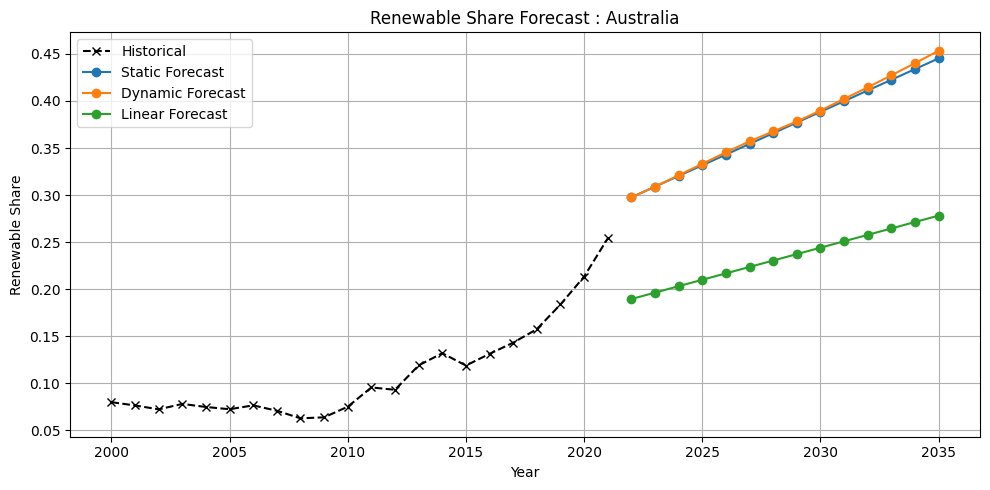

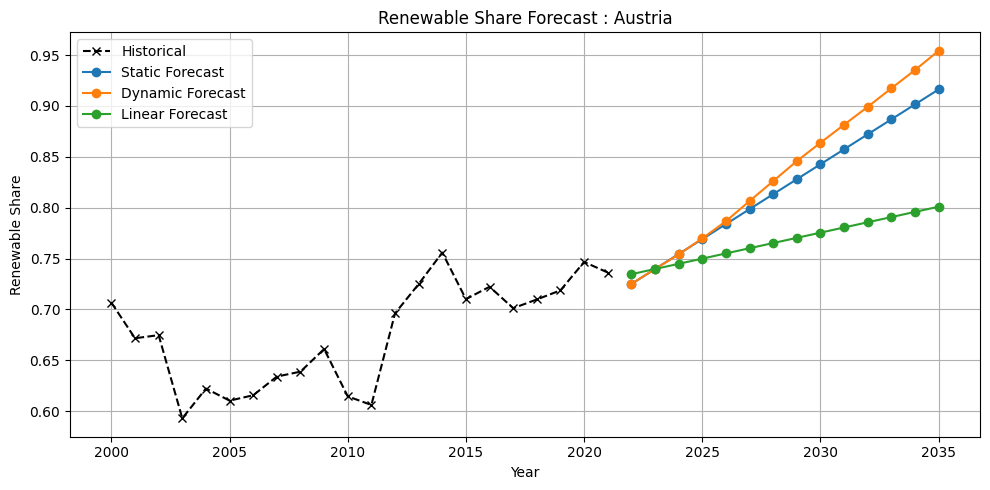

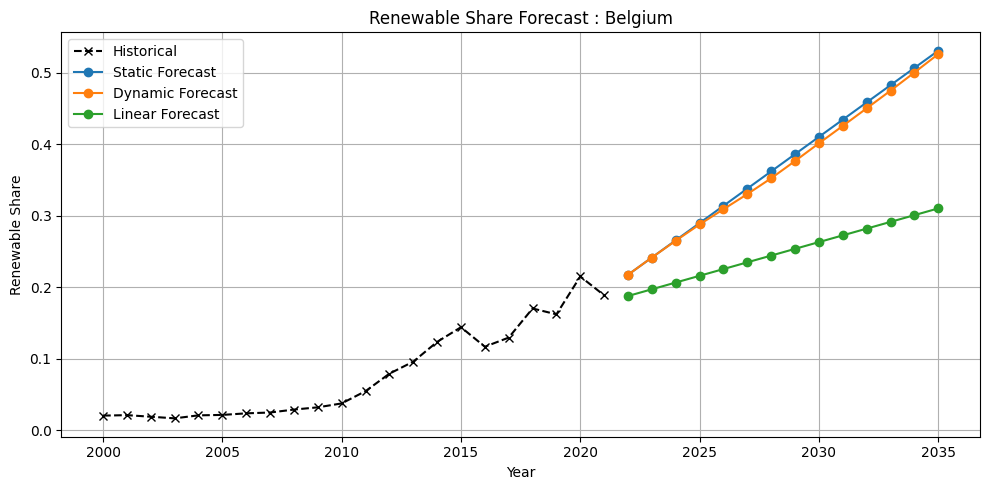

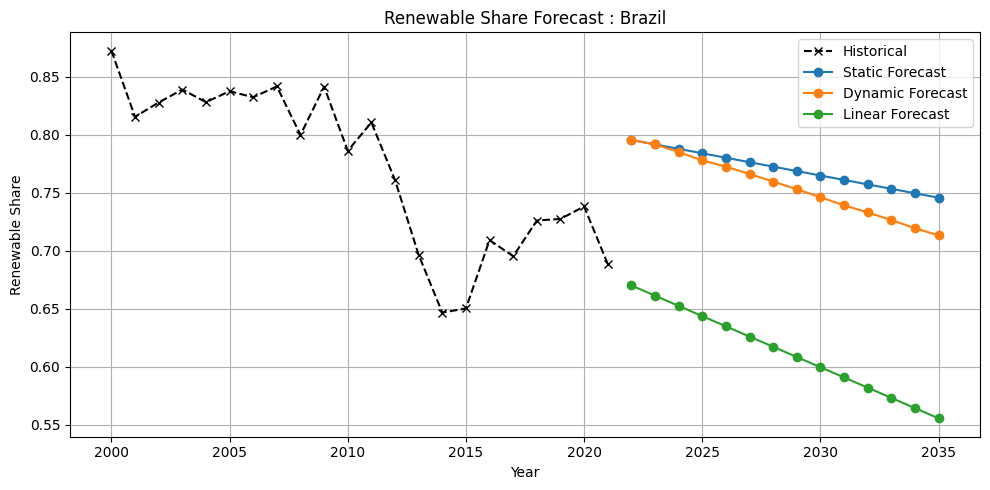

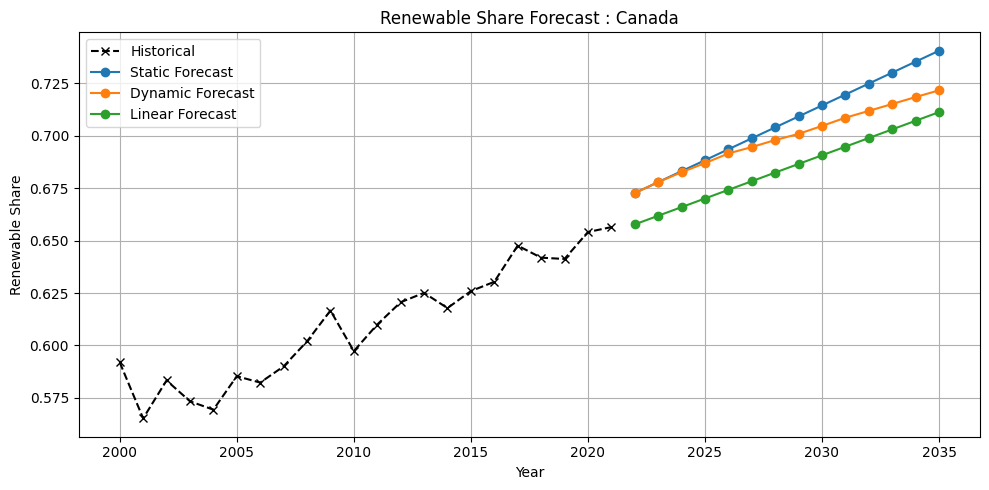

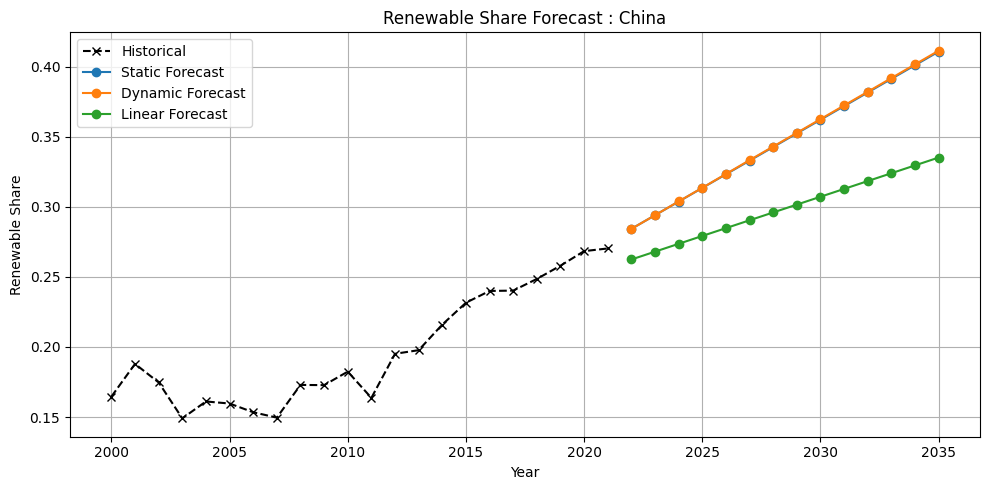

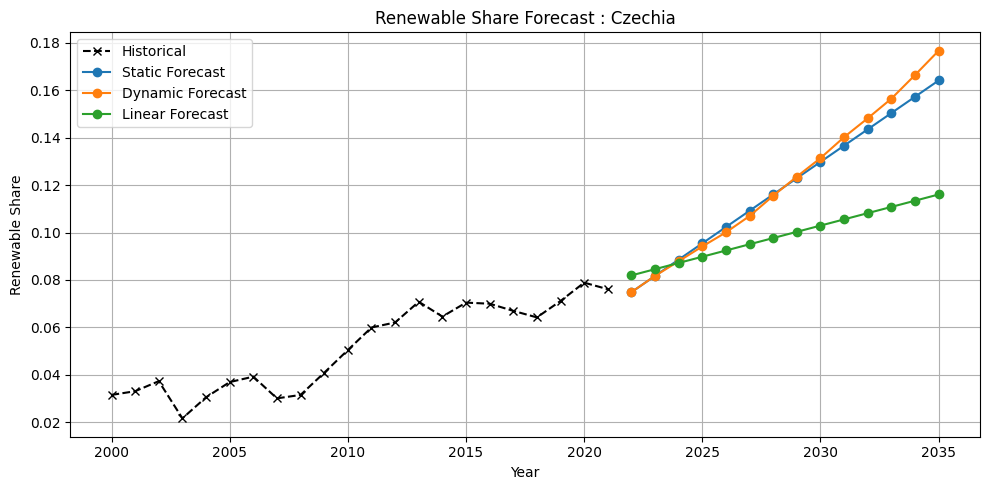

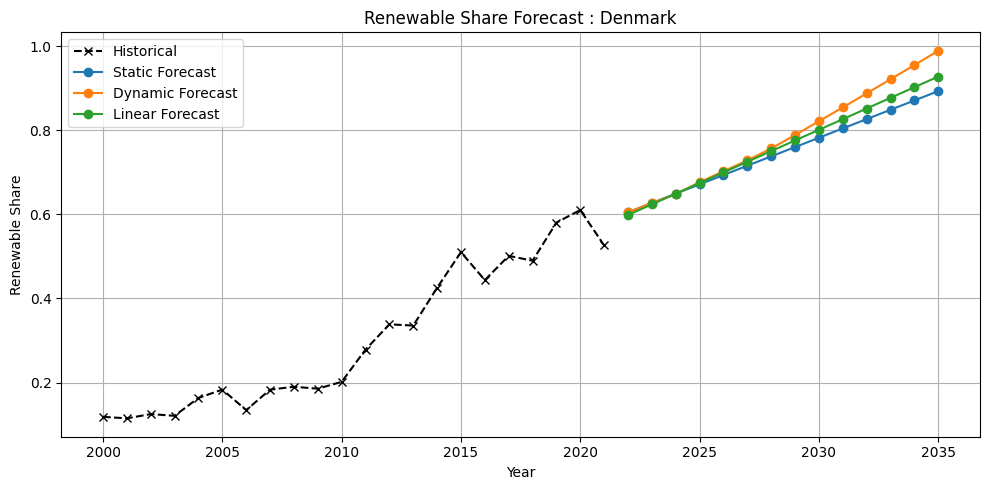

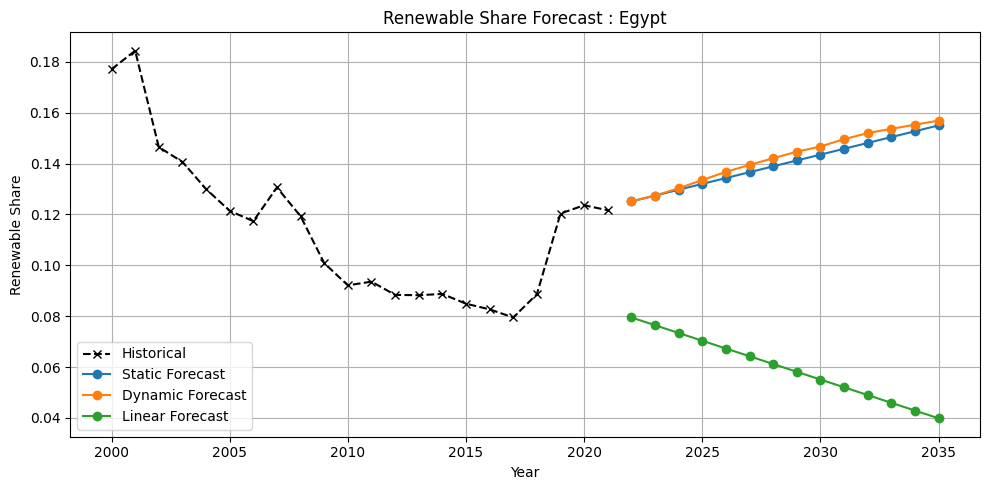

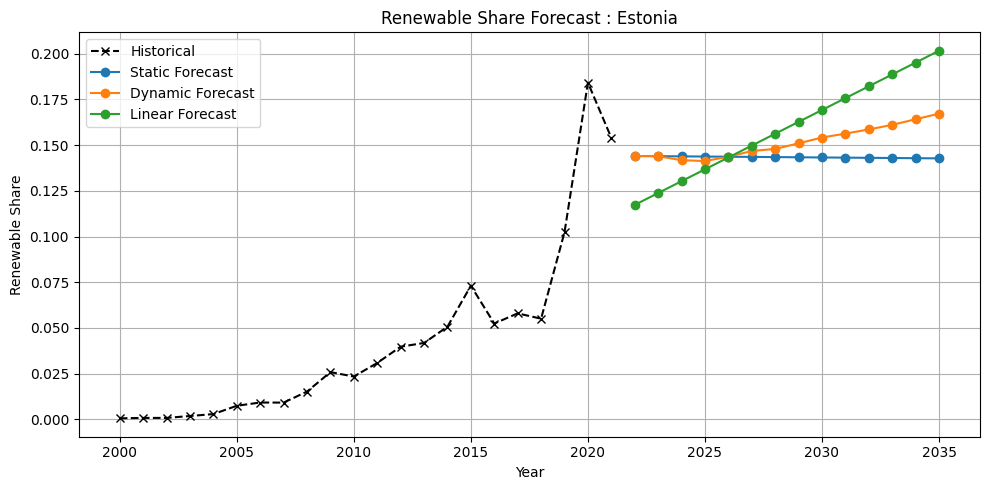

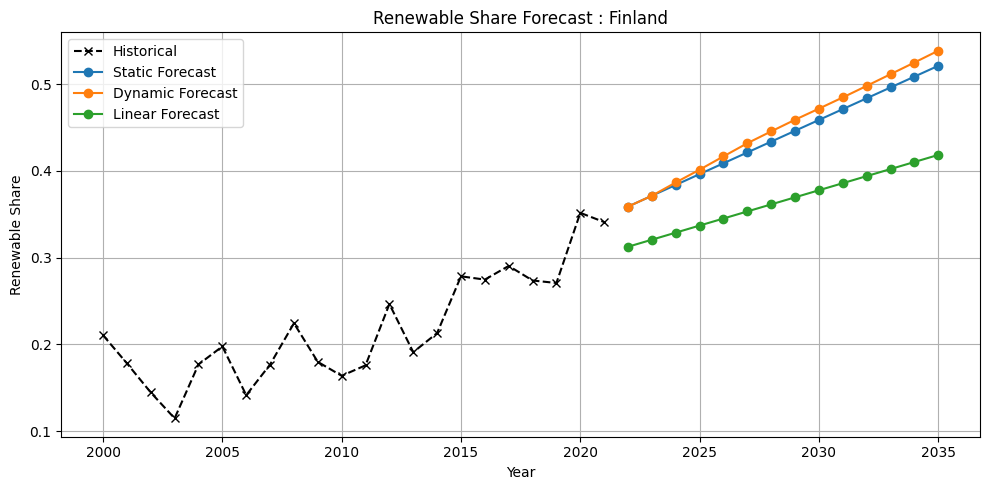

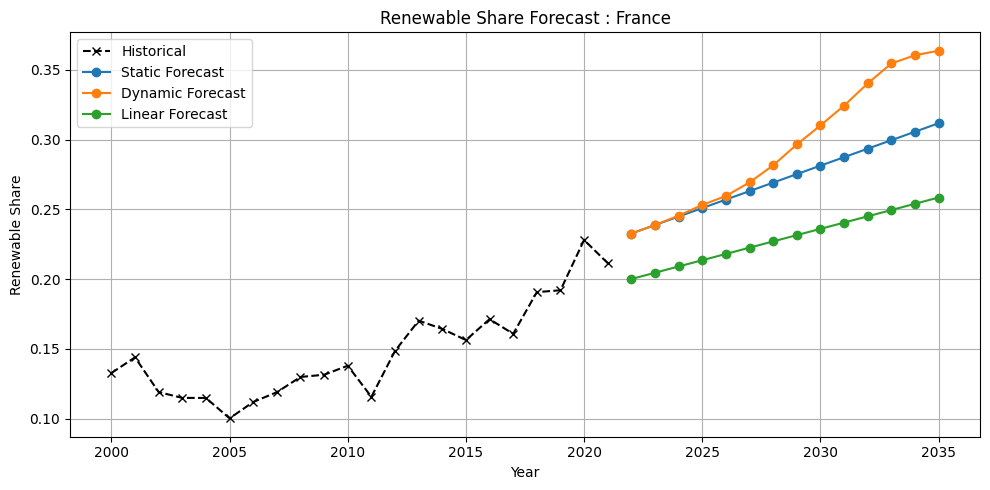

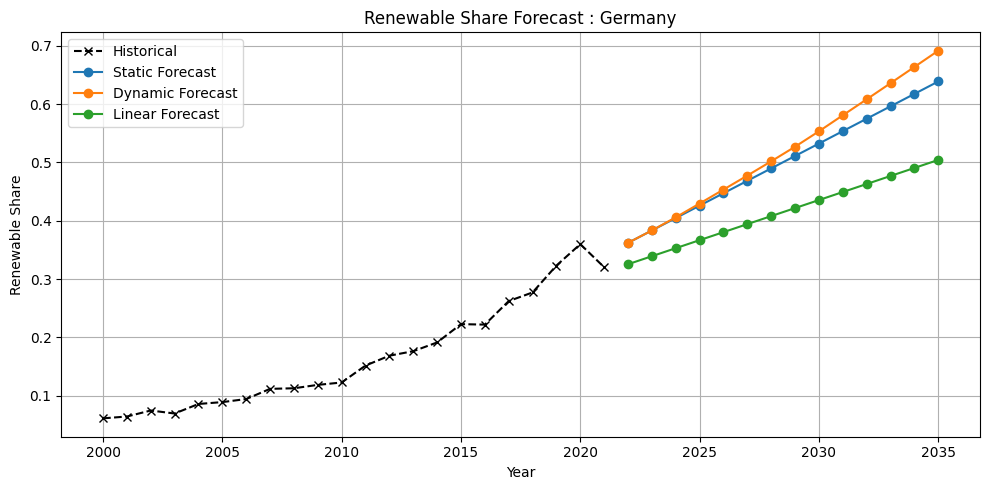

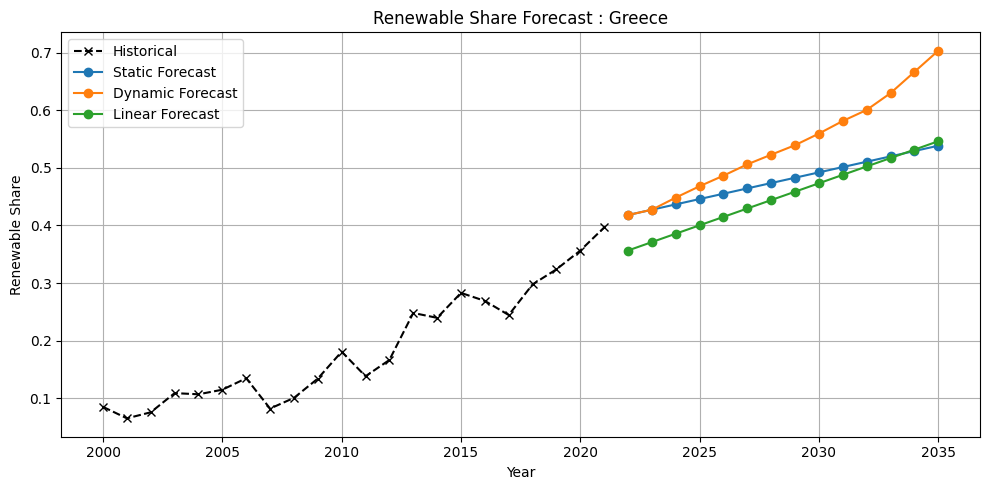

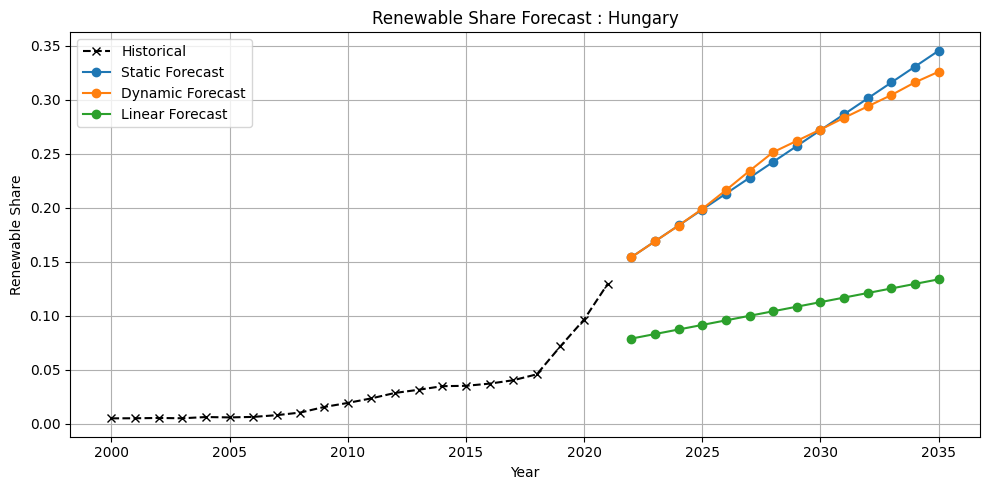

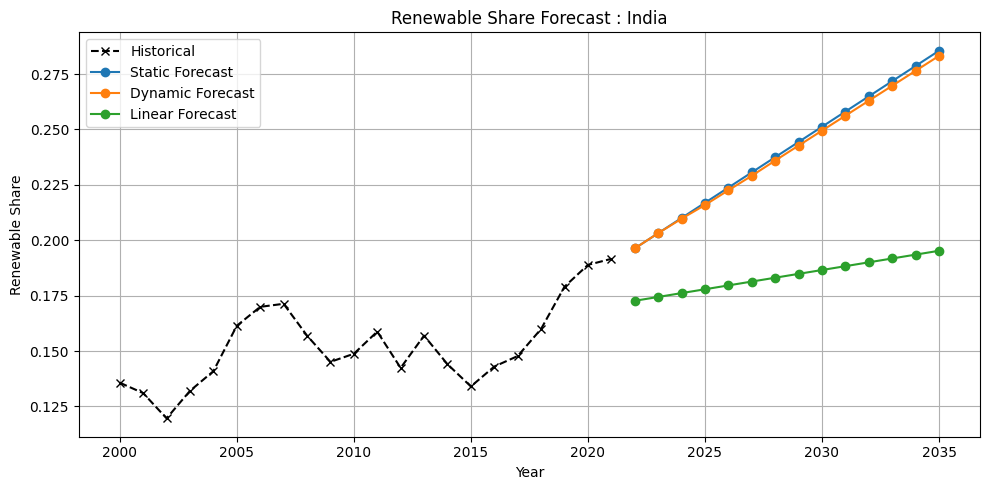

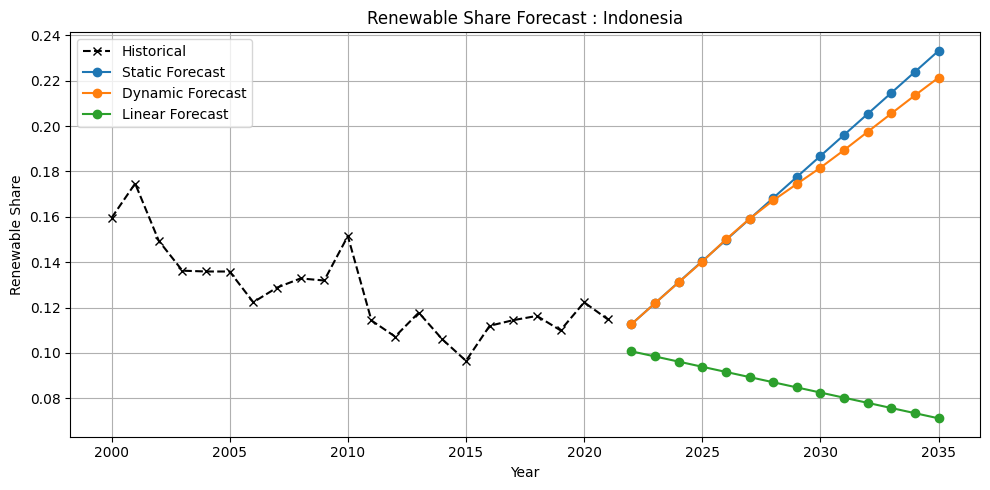

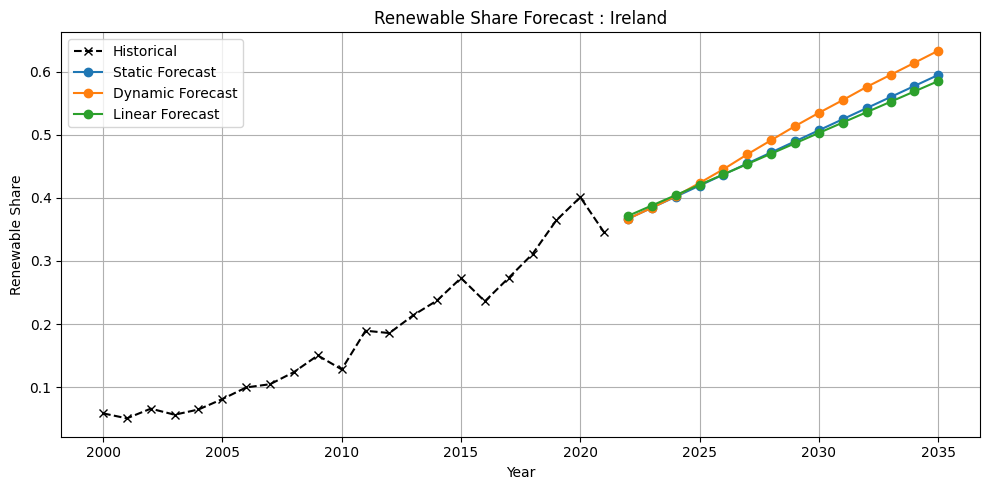

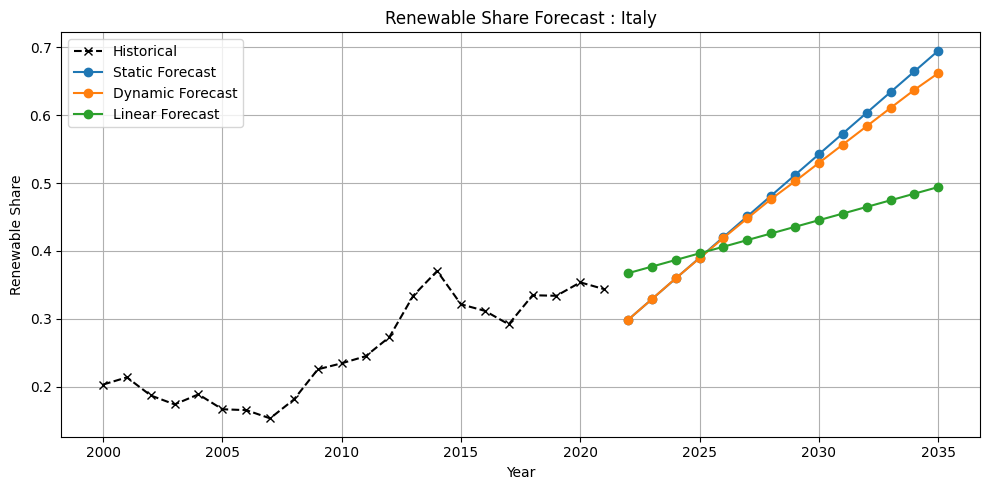

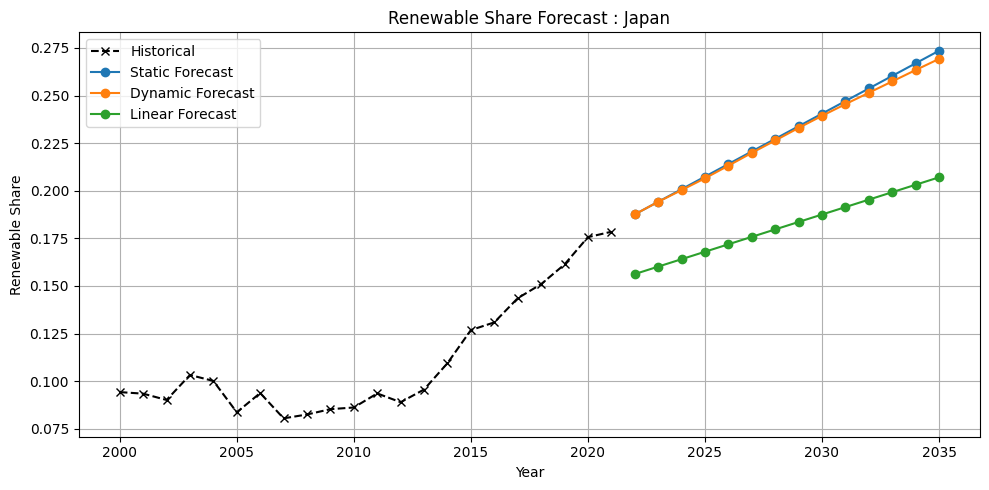

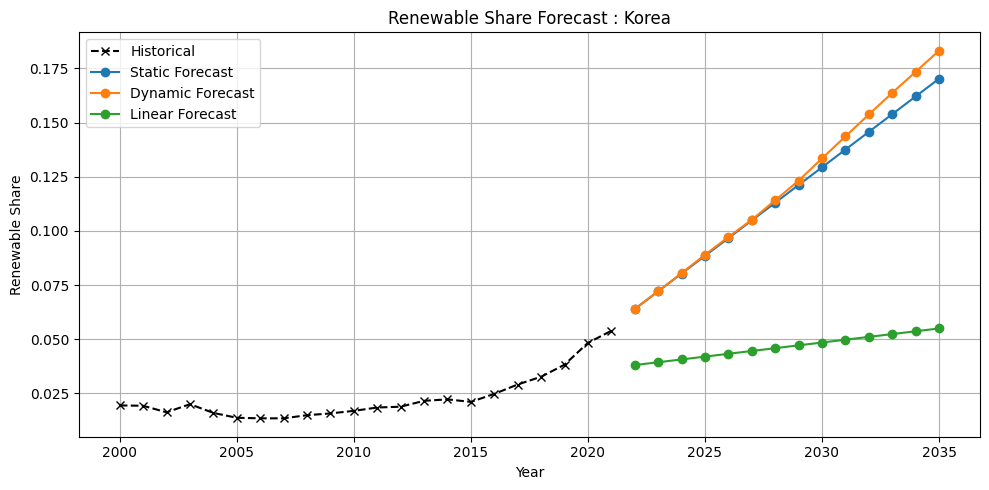

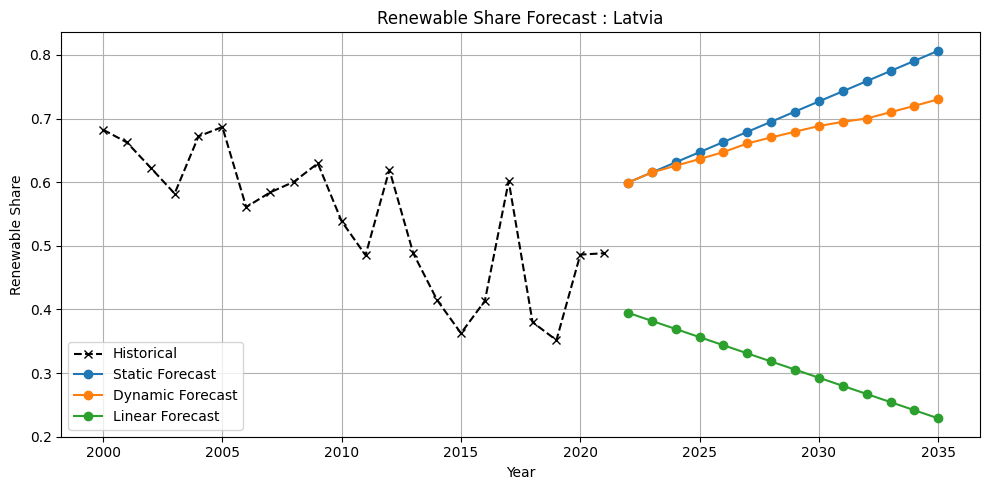

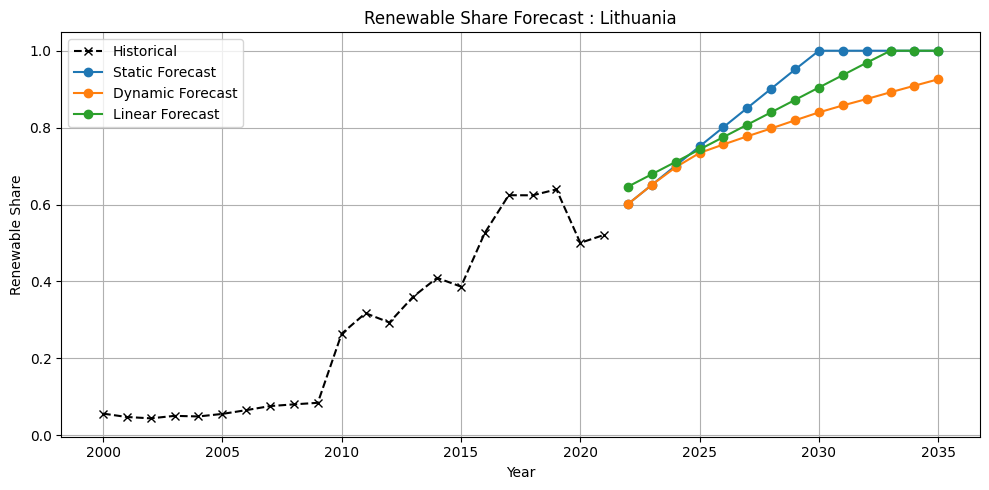

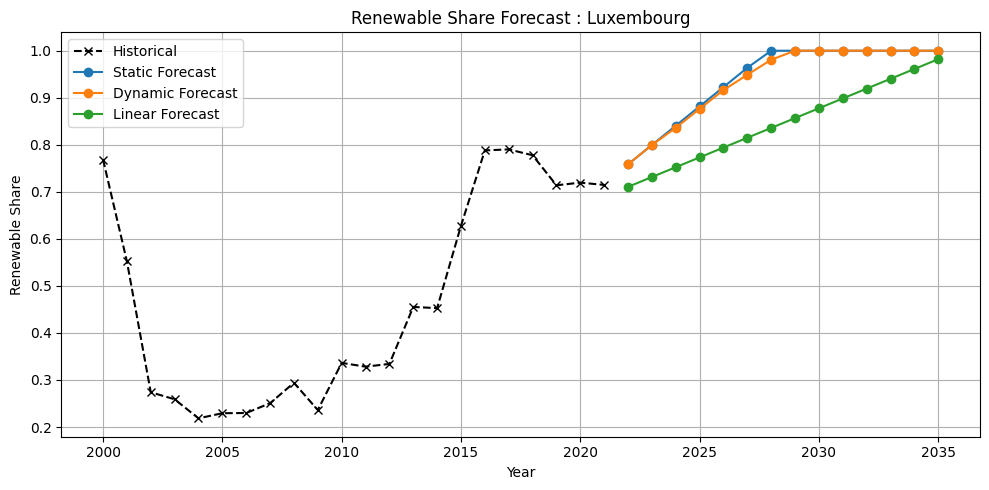

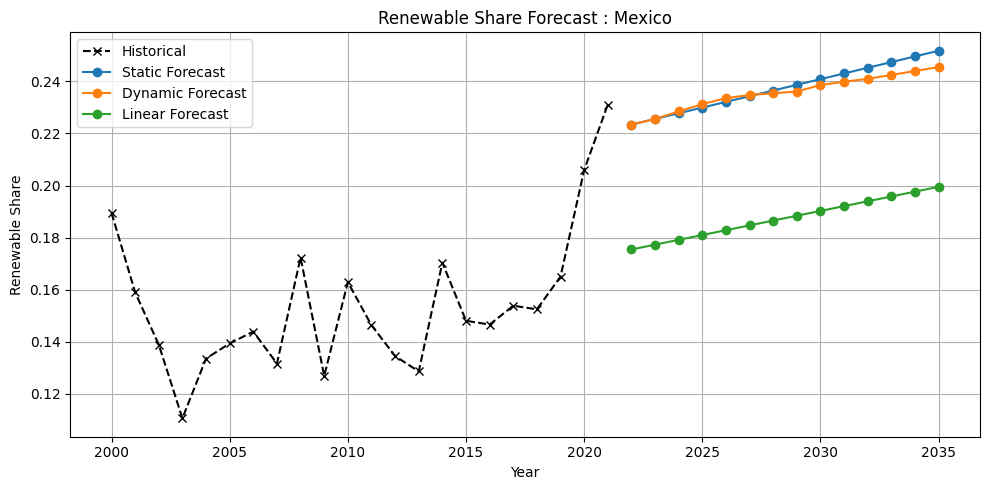

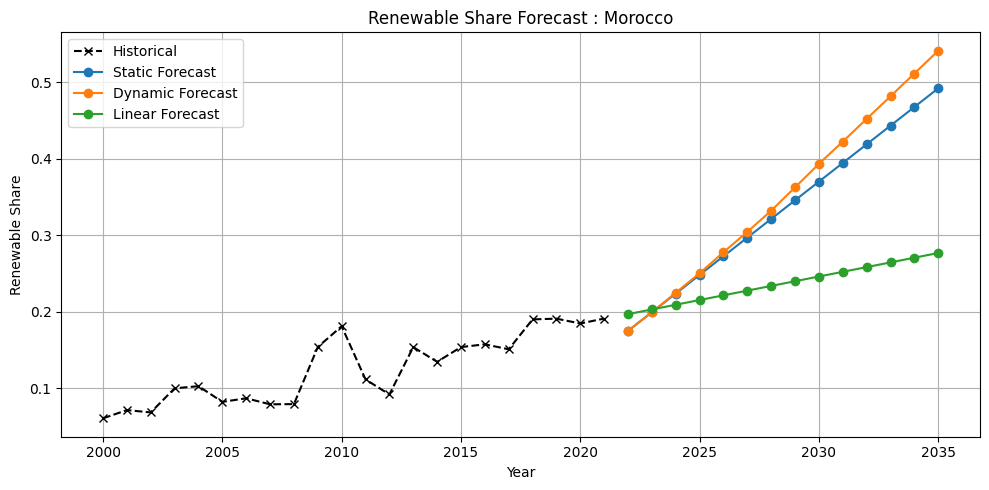

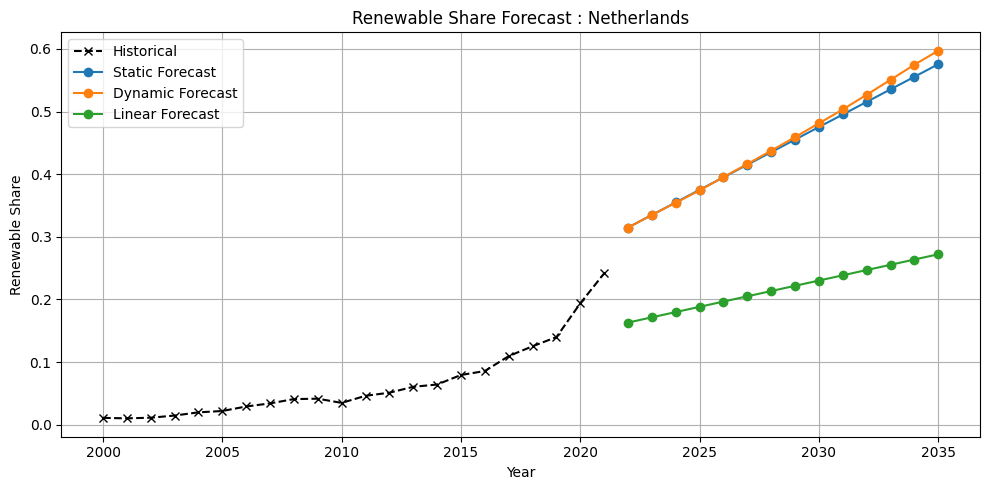

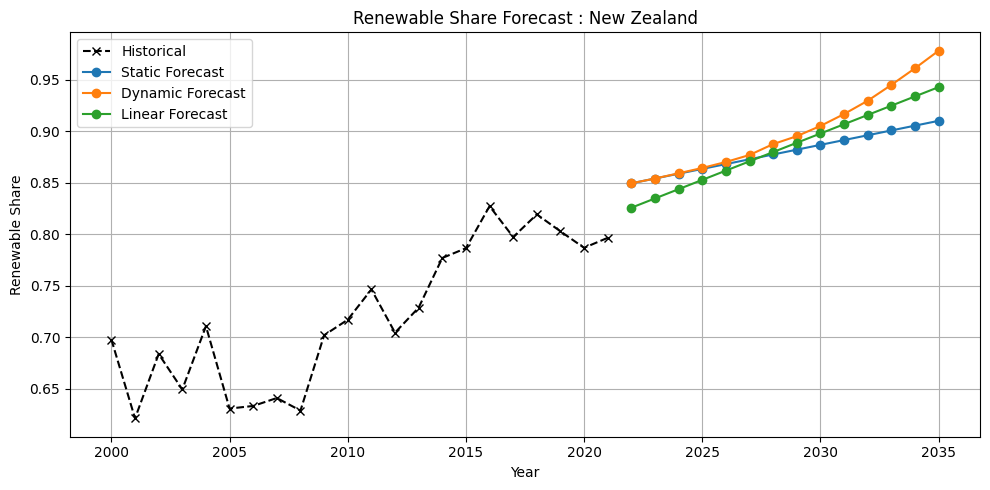

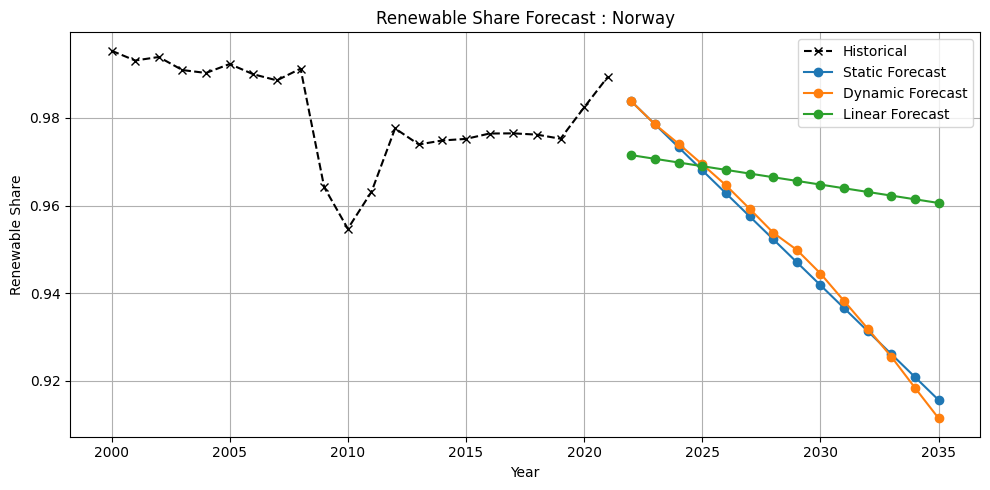

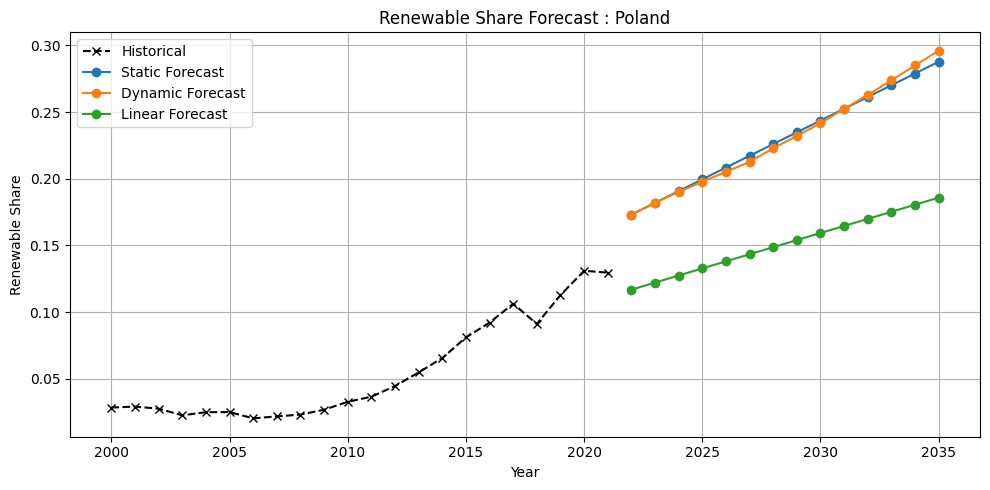

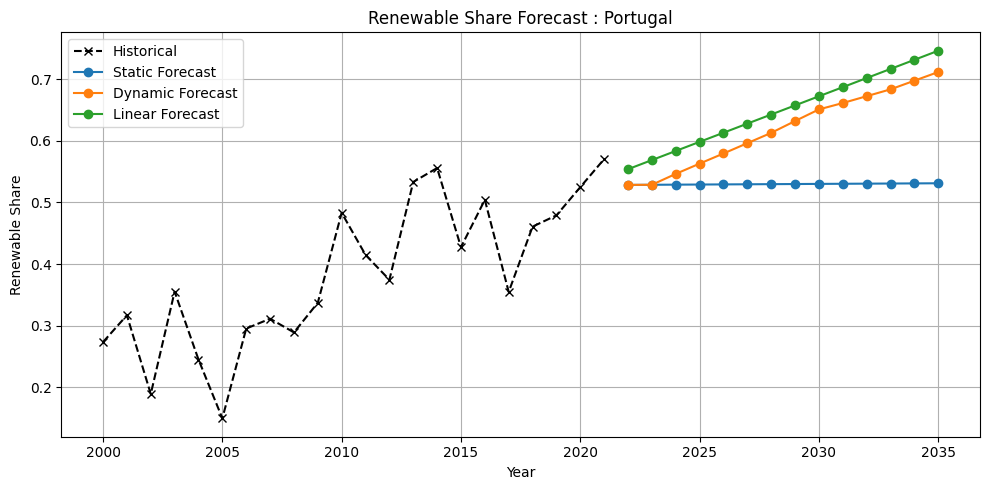

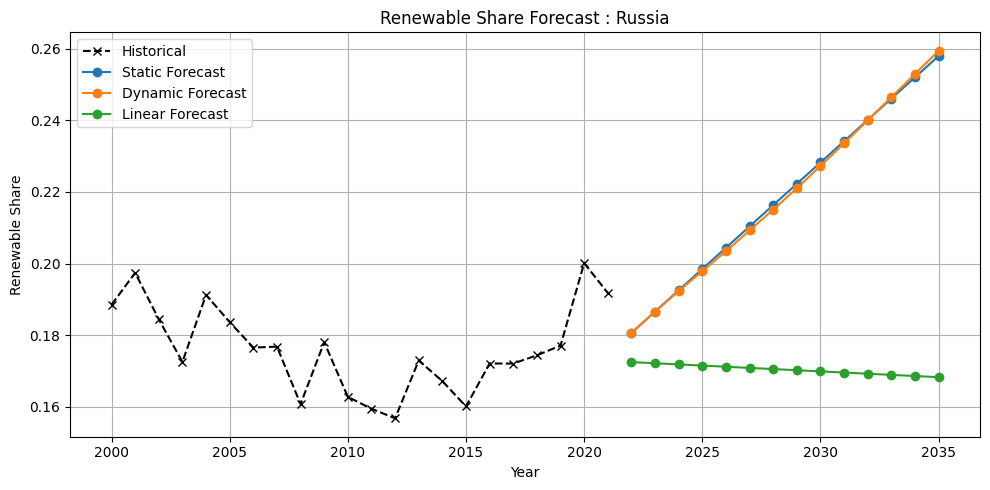

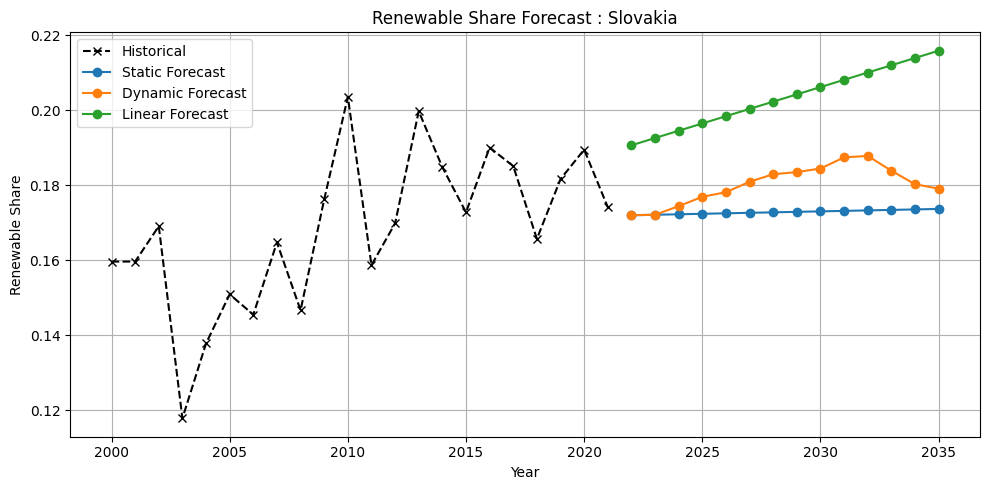

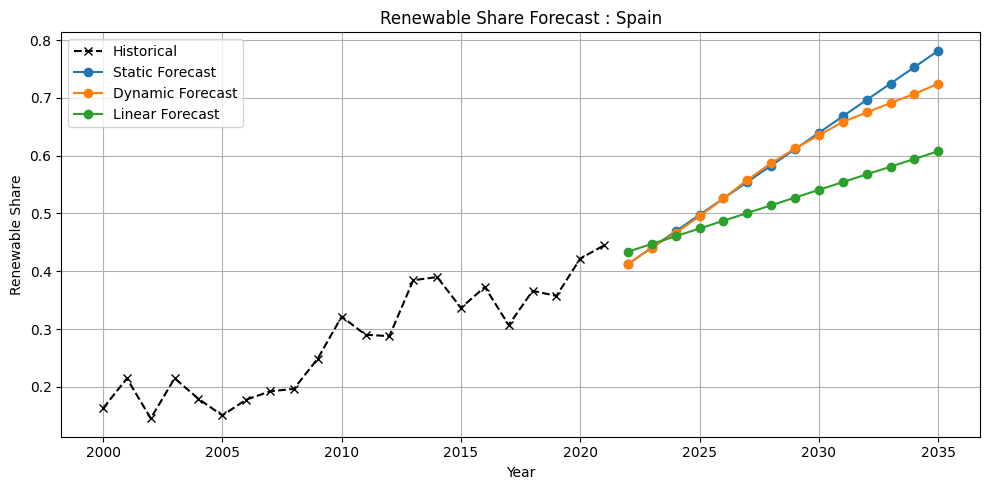

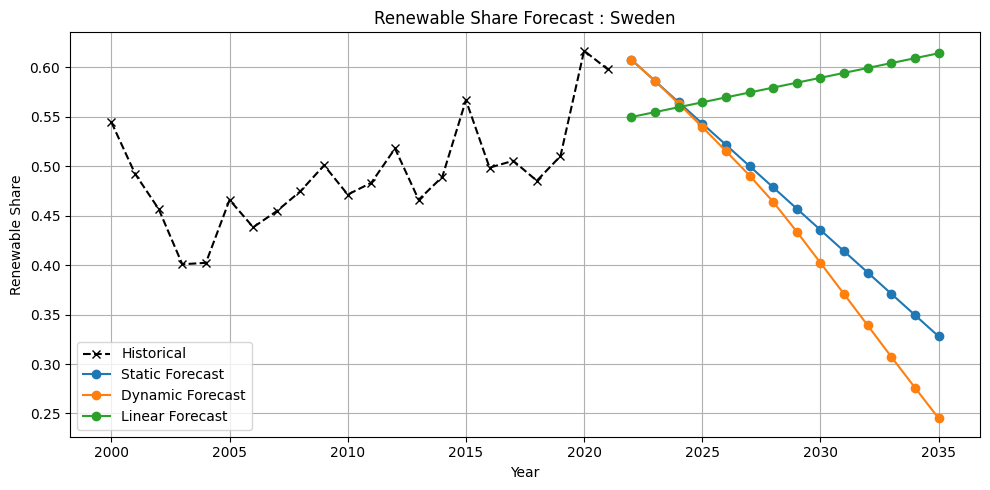

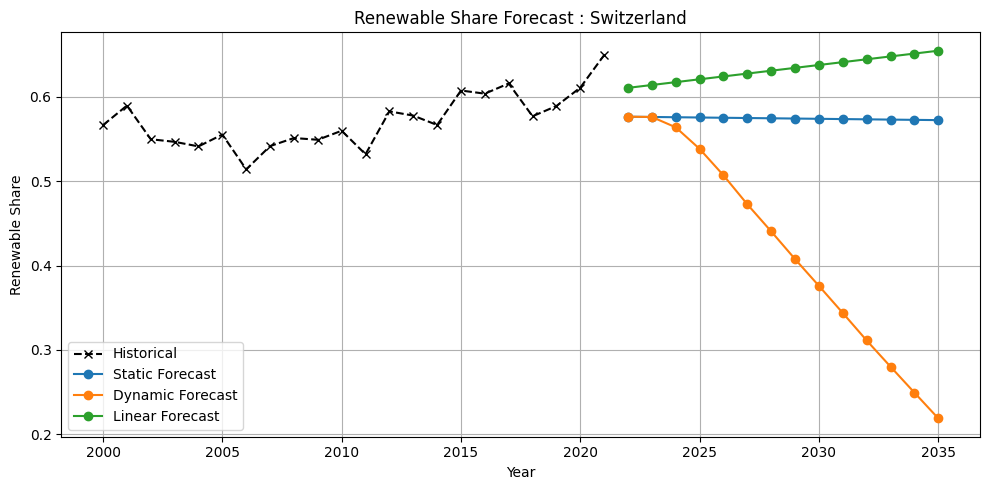

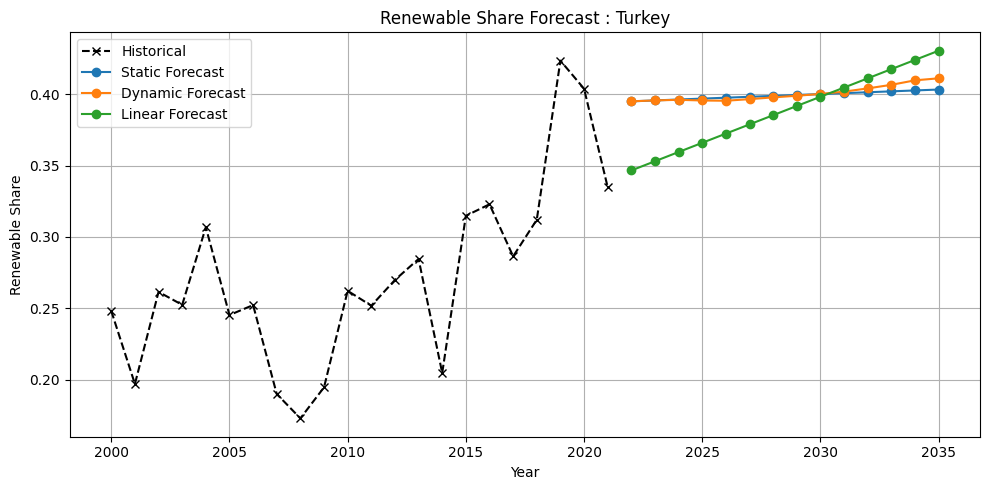

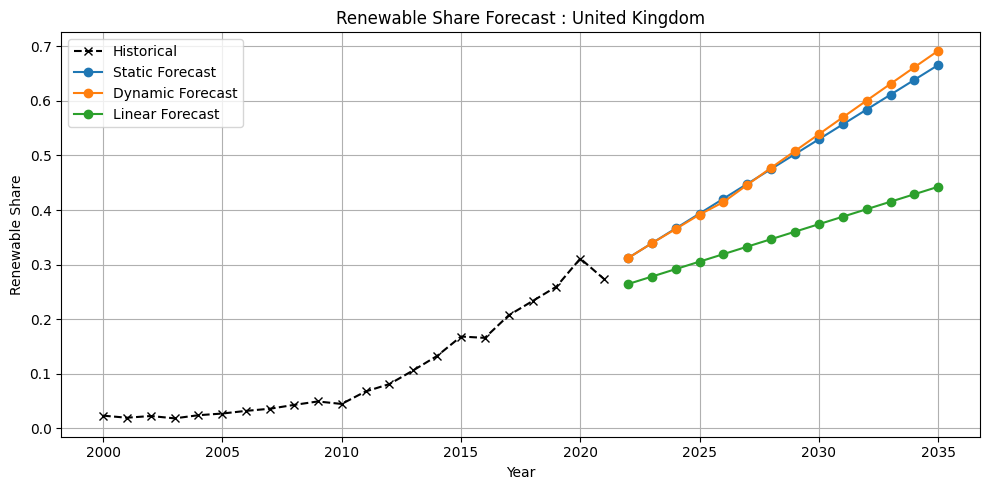

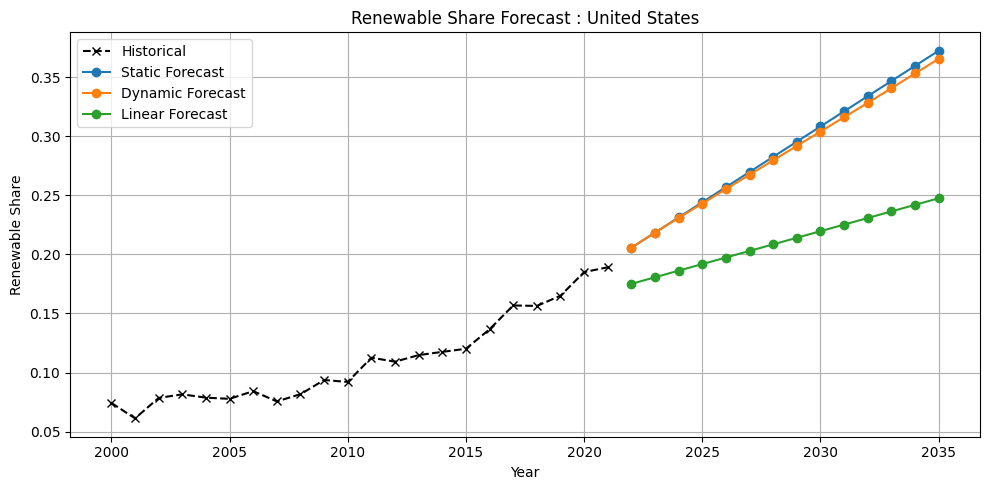

In [ ]:
def plot_forecast(country): 
    static_line = forecast_df[forecast_df["country"] == country]
    dynamic_line = forecast_df_dynamic[forecast_df_dynamic["country"] == country]
    linear_line = forecast_df_linear[forecast_df_linear["country"] == country]
    history = data3[data3["country"] == country][["year", "true_renew_share"]]
    
    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(history["year"], history["true_renew_share"], color="black", linestyle="--", marker="x", label="Historical")
    ax.plot(static_line["year"], static_line["renew_share"], marker="o", label="Static Forecast")
    ax.plot(dynamic_line["year"], dynamic_line["renew_share"], marker="o", label="Dynamic Forecast")
    ax.plot(linear_line["year"], linear_line["renew_share"], marker="o", label="Linear Forecast")
    ax.set_title(f"Renewable Share Forecast : {country}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Renewable Share")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    if country == "United States":
        plt.savefig("../results/best_forecast_plot1.png", dpi=150, bbox_inches="tight")
    if country == "Greece":
        plt.savefig("../results/best_forecast_plot2.png", dpi=150, bbox_inches="tight")
    if country == "New Zealand":
        plt.savefig("../results/best_forecast_plot3.png", dpi=150, bbox_inches="tight")
    plt.show()

for country in forecast_df["country"].unique():
    plot_forecast(country)

In [72]:
all_comparisons = []

for country in forecast_df["country"].unique():
    static = forecast_df[forecast_df["country"] == country][["year", "renew_share"]].copy()
    static.rename(columns={"renew_share": "static_share"}, inplace=True)

    dynamic = forecast_df_dynamic[forecast_df_dynamic["country"] == country][["year", "renew_share"]].copy()
    dynamic.rename(columns={"renew_share": "dynamic_share"}, inplace=True)

    linear = forecast_df_linear[forecast_df_linear["country"] == country][["year", "renew_share"]].copy()
    linear.rename(columns={"renew_share": "linear_share"}, inplace=True)

    comp = static.merge(dynamic, on="year").merge(linear, on="year").sort_values("year")
    comp["country"] = country
    comp["static_change"] = comp["static_share"].diff()
    comp["dynamic_change"] = comp["dynamic_share"].diff()
    comp["divergence"] = comp["dynamic_share"] - comp["static_share"]
    comp["linear_change"] = comp["linear_share"].diff()
    all_comparisons.append(comp)

full_comparison_df = pd.concat(all_comparisons, ignore_index=True)
full_comparison_df.to_csv("static_vs_dynamic_vs_linear_forecast.csv", index=False)

In [73]:
historical_df = data3[["country", "year", "true_renew_share"]].sort_values(["country", "year"])
historical_df.to_csv("historical_renew_share.csv", index=False)

In [74]:
switzerland_trends = feature_trends[feature_trends["country"] == "Switzerland"].T
switzerland_trends.columns = ["trend"]
switzerland_trends = switzerland_trends[switzerland_trends.index != "country"]
switzerland_trends["trend"] = switzerland_trends["trend"].astype(float)

print("Negative trending features:")
print(switzerland_trends[switzerland_trends["trend"] < 0].sort_values("trend"))

print("\nPositive trending features:")
print(switzerland_trends[switzerland_trends["trend"] > 0].sort_values("trend", ascending=False))

Negative trending features:
                                      trend
tfc_oil_trend                  -3505.000000
tes_oil_trend                  -3097.000000
tfc_coal_trend                  -181.000000
tes_coal_trend                  -181.000000
tes_nucelar_trend               -142.000000
co2_emissions_per_capita_trend    -0.045742

Positive trending features:
                                   trend
tes_natural_gas_trend         3102.00000
tfc_natural_gas_trend         2949.00000
tes_biofuels_trend            2836.00000
tfc_biofuels_trend            1490.00000
tfc_electricity_trend         1260.00000
gdp_per_capita_trend           689.52481
tes_solar_wind_otr_trend       587.00000
tfc_heat_trend                 528.00000
tfc_solar_wind_trend            78.00000
year_trend                       1.00000
elec_consumption_total_trend     0.52700
